/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_91874/2011234480.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_91874/2011234480.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].sum().to_frame()
13:23:49 - cmdstanpy - INFO - Chain [1] start processing
13:23:49 - cmdstanpy - INFO - Chain [1] done processing
13:23:49 - cmdstanpy - INFO - Chain [1] start processing
13:23:49 - cmdstanpy - INFO - Chain [1] done processing
13:23:49 - cmdstanpy - INFO - Chain [1] start processing
13:23:49 - cmdstanpy - INFO - Chain [1] done processing



=== PROPHET – OFF‑shore TEST METRICS ===
Monthly  MSE=64,199,743,877,873,440.00  RMSE=253,376,683.77  MAE=184,221,240.82  R²=0.2263  MAPE=13.40%
Weekly   MSE=20,906,560,751,819,572.00  RMSE=144,591,012.00  MAE=116,942,295.28  R²=-0.0659  MAPE=65.99%
Daily    MSE=903,045,107,049,975.62  RMSE=30,050,708.93  MAE=27,373,605.62  R²=-0.1527  MAPE=355.66%


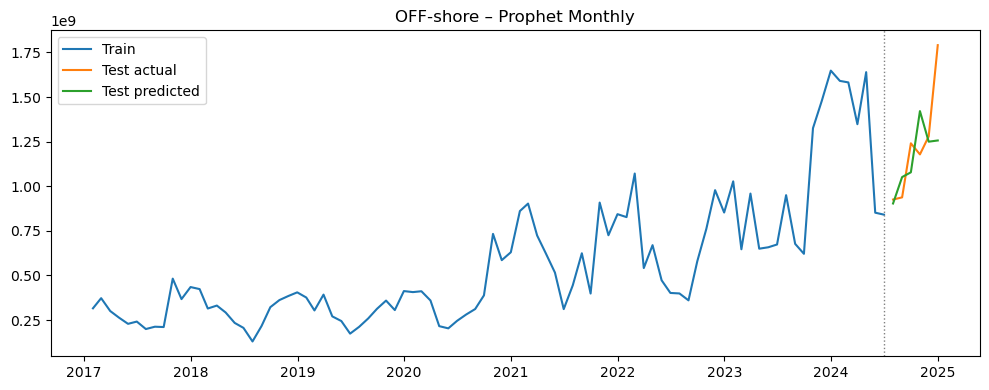

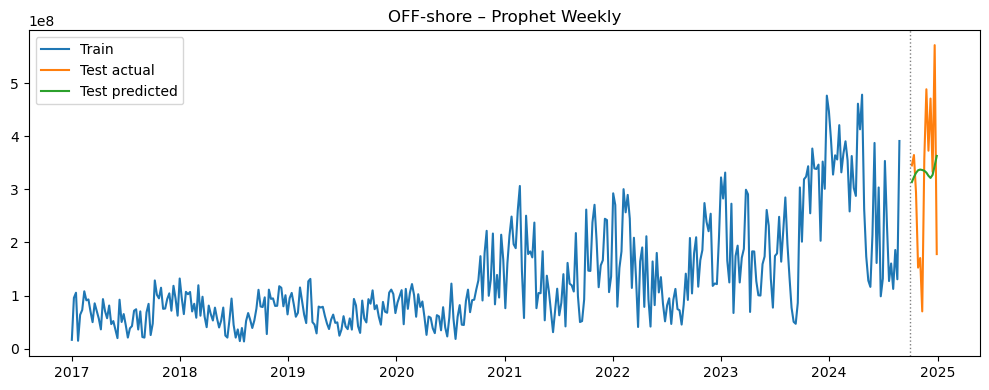

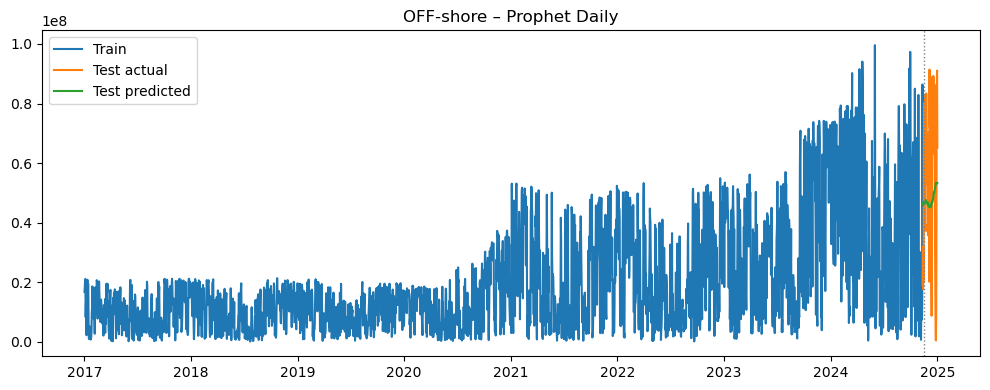

In [11]:
# ================================================================
#  PROPHET  –  Monthly / Weekly / Daily
# ================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet

DATA_PATH = "/Users/polina/Watts-next/data/final_offshore_data_2017_2025.csv" 
SITE      = "OFF‑shore" 

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"]  = df["hour_str"].astype(int) - 1
df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]     = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATE ---------------------------------------------------------
def make_agg(rule):
    g = df.resample(rule)["y"].sum().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)

df_M, df_W, df_D = map(make_agg, ["M", "W", "D"])

# 3) SPLIT -----------------------------------------------------
def split(df_, train_end, val_start, val_end, test_start, test_end):
    tr  = df_[df_.ds <= train_end].copy()
    val = df_[(df_.ds >= val_start) & (df_.ds < val_end)].copy()
    te  = df_[(df_.ds >= test_start) & (df_.ds < test_end)].copy()
    return tr, val, te

m_tr, m_val, m_te = split(df_M, "2024-06-30", "2024-01-01", "2024-07-01",
                                    "2024-07-01", "2025-01-01")
w_tr, w_val, w_te = split(df_W, "2024-08-31", "2024-07-01", "2024-10-01",
                                    "2024-10-01", "2025-01-01")
d_tr, d_val, d_te = split(df_D, "2024-11-13", "2024-10-02", "2024-11-13",
                                    "2024-11-13", "2025-01-12")

# 4) TRAIN -------------------------------------------------------------
model_M = Prophet(yearly_seasonality=True).fit(m_tr[["ds","y"]])
model_W = Prophet(yearly_seasonality=True).fit(w_tr[["ds","y"]])
model_D = Prophet(yearly_seasonality=True, weekly_seasonality=True).fit(d_tr[["ds","y"]])

# 5) PREDICT + METRICS -------------------------------------------------
def mape(a,f): return np.mean(np.abs((a-f)/(a+1e-6)))*100
def eval(model, test_df):
    fc = model.predict(test_df[["ds"]])[["ds","yhat"]]
    merged = test_df.merge(fc, on="ds")
    y, yhat = merged.y.values, merged.yhat.values
    mse  = mean_squared_error(y,yhat); rmse=np.sqrt(mse)
    return mse, rmse, mean_absolute_error(y,yhat), r2_score(y,yhat), mape(y,yhat)

metrics_M = eval(model_M, m_te)
metrics_W = eval(model_W, w_te)
metrics_D = eval(model_D, d_te)

print("\n=== PROPHET –", SITE, "TEST METRICS ===")
for lbl,m in zip(["Monthly","Weekly","Daily"], [metrics_M,metrics_W,metrics_D]):
    mse,rmse,mae,r2,mape = m
    print(f"{lbl:<7}  MSE={mse:,.2f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}  MAPE={mape:,.2f}%")

# 6) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title, vline):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(fc["ds"], fc["yhat"], label="Test predicted")
    plt.axvline(pd.to_datetime(vline), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te,
         model_M.predict(m_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Monthly", "2024-07-01")
plot_one(w_tr, w_te,
         model_W.predict(w_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Weekly",  "2024-10-01")
plot_one(d_tr, d_te,
         model_D.predict(d_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Daily",   "2024-11-15")
# ================================================================


/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_91874/1418074028.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_91874/1418074028.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  g = df.resample(rule)["y"].sum().to_frame()
13:27:41 - cmdstanpy - INFO - Chain [1] start processing
13:27:41 - cmdstanpy - INFO - Chain [1] done processing
13:27:41 - cmdstanpy - INFO - Chain [1] start processing
13:27:41 - cmdstanpy - INFO - Chain [1] done processing
13:27:41 - cmdstanpy - INFO - Chain [1] start processing
13:27:42 - cmdstanpy - INFO - Chain [1] done processing



=== PROPHET – ON‑shore TEST METRICS ===
Monthly  MSE=75,416,471,287,909,152.00  RMSE=274,620,595.16  MAE=240,935,521.74  R²=0.1150  MAPE=18.02%
Weekly   MSE=27,489,987,456,735,900.00  RMSE=165,801,047.82  MAE=131,010,212.06  R²=-0.1390  MAPE=75.72%
Daily    MSE=1,060,037,569,026,842.50  RMSE=32,558,218.15  MAE=29,532,452.38  R²=-0.0840  MAPE=381.57%


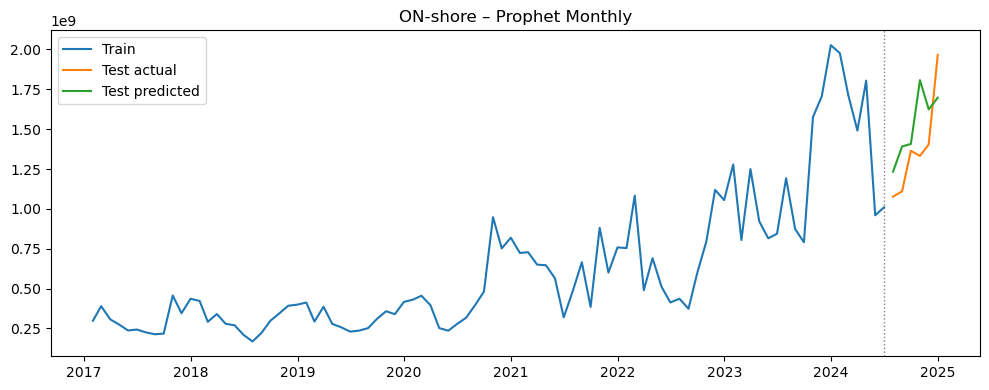

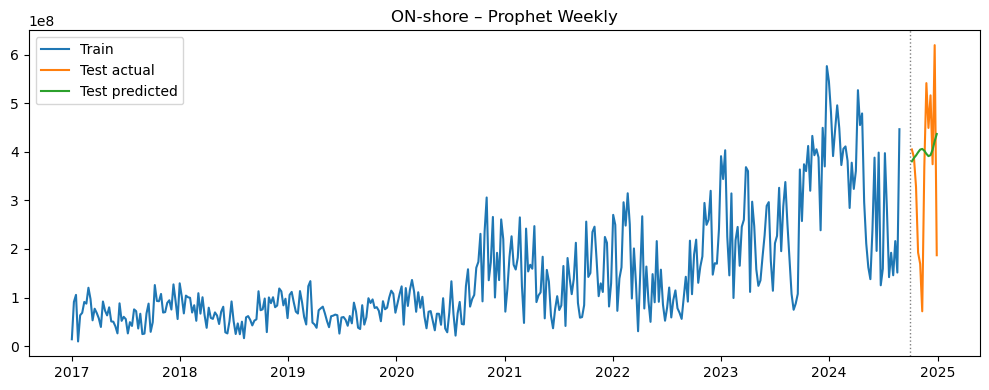

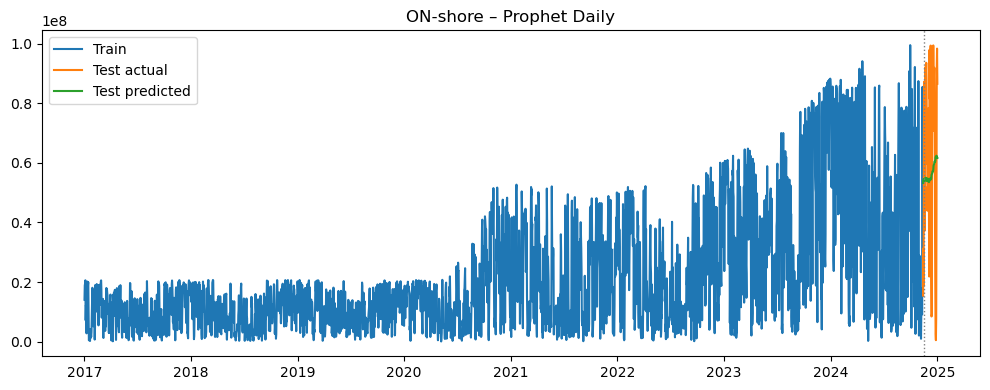

In [12]:
# ================================================================
#  PROPHET  –  Monthly / Weekly / Daily
# ================================================================
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet

DATA_PATH = "/Users/polina/Watts-next/data/final_onshore_data_2017_2025.csv" 
SITE      = "ON‑shore" 

# 1) LOAD & PREP -------------------------------------------------------
df = pd.read_csv(DATA_PATH)
df[["date","hour_str"]] = df["correct_days"].str.rsplit("-", n=1, expand=True)
df["hour"]  = df["hour_str"].astype(int) - 1
df["ds"]    = pd.to_datetime(df["date"]) + pd.to_timedelta(df["hour"], unit="H")
df["y"]     = df["volume"]
df = df.sort_values("ds").set_index("ds")

# 2) AGGREGATE ---------------------------------------------------------
def make_agg(rule):
    g = df.resample(rule)["y"].sum().to_frame()
    g["ds"] = g.index
    return g.reset_index(drop=True)

df_M, df_W, df_D = map(make_agg, ["M", "W", "D"])

# 3) SPLIT ФУНКЦИЯ -----------------------------------------------------
def split(df_, train_end, val_start, val_end, test_start, test_end):
    tr  = df_[df_.ds <= train_end].copy()
    val = df_[(df_.ds >= val_start) & (df_.ds < val_end)].copy()
    te  = df_[(df_.ds >= test_start) & (df_.ds < test_end)].copy()
    return tr, val, te

m_tr, m_val, m_te = split(df_M, "2024-06-30", "2024-01-01", "2024-07-01",
                                    "2024-07-01", "2025-01-01")
w_tr, w_val, w_te = split(df_W, "2024-08-31", "2024-07-01", "2024-10-01",
                                    "2024-10-01", "2025-01-01")
d_tr, d_val, d_te = split(df_D, "2024-11-13", "2024-10-02", "2024-11-13",
                                    "2024-11-13", "2025-01-12")

# 4) TRAIN -------------------------------------------------------------
model_M = Prophet(yearly_seasonality=True).fit(m_tr[["ds","y"]])
model_W = Prophet(yearly_seasonality=True).fit(w_tr[["ds","y"]])
model_D = Prophet(yearly_seasonality=True, weekly_seasonality=True).fit(d_tr[["ds","y"]])

# 5) PREDICT + METRICS -------------------------------------------------
def mape(a,f): return np.mean(np.abs((a-f)/(a+1e-6)))*100
def eval(model, test_df):
    fc = model.predict(test_df[["ds"]])[["ds","yhat"]]
    merged = test_df.merge(fc, on="ds")
    y, yhat = merged.y.values, merged.yhat.values
    mse  = mean_squared_error(y,yhat); rmse=np.sqrt(mse)
    return mse, rmse, mean_absolute_error(y,yhat), r2_score(y,yhat), mape(y,yhat)

metrics_M = eval(model_M, m_te)
metrics_W = eval(model_W, w_te)
metrics_D = eval(model_D, d_te)

print("\n=== PROPHET –", SITE, "TEST METRICS ===")
for lbl,m in zip(["Monthly","Weekly","Daily"], [metrics_M,metrics_W,metrics_D]):
    mse,rmse,mae,r2,mape = m
    print(f"{lbl:<7}  MSE={mse:,.2f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}  R²={r2:.4f}  MAPE={mape:,.2f}%")

# 6) PLOTS -------------------------------------------------------------
def plot_one(tr, te, fc, title, vline):
    plt.figure(figsize=(10,4))
    plt.plot(tr["ds"], tr["y"], label="Train")
    plt.plot(te["ds"], te["y"], label="Test actual")
    plt.plot(fc["ds"], fc["yhat"], label="Test predicted")
    plt.axvline(pd.to_datetime(vline), ls=":", lw=1, c="gray")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

plot_one(m_tr, m_te,
         model_M.predict(m_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Monthly", "2024-07-01")
plot_one(w_tr, w_te,
         model_W.predict(w_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Weekly",  "2024-10-01")
plot_one(d_tr, d_te,
         model_D.predict(d_te[["ds"]])[["ds","yhat"]],
         f"{SITE} – Prophet Daily",   "2024-11-15")
# ================================================================
